**SWE-Bench charged tokens (session + replay).** Codex / gpt-5.6-luna,
300 tasks. The top row keeps the clean-solve baseline. The bottom
row does not zoom the same lines: it splits the recovery gap into
replay (the part checkpoint and abort always pay) and the paired
ratio on each repository. (a) median charged tokens by task scale;
(b) median charged tokens by repository; (c) median charged tokens
stacked as session plus independent-doc replay; (d) paired median
charged-token ratio versus AgentTX. Line colors match the earlier
FAST figures.


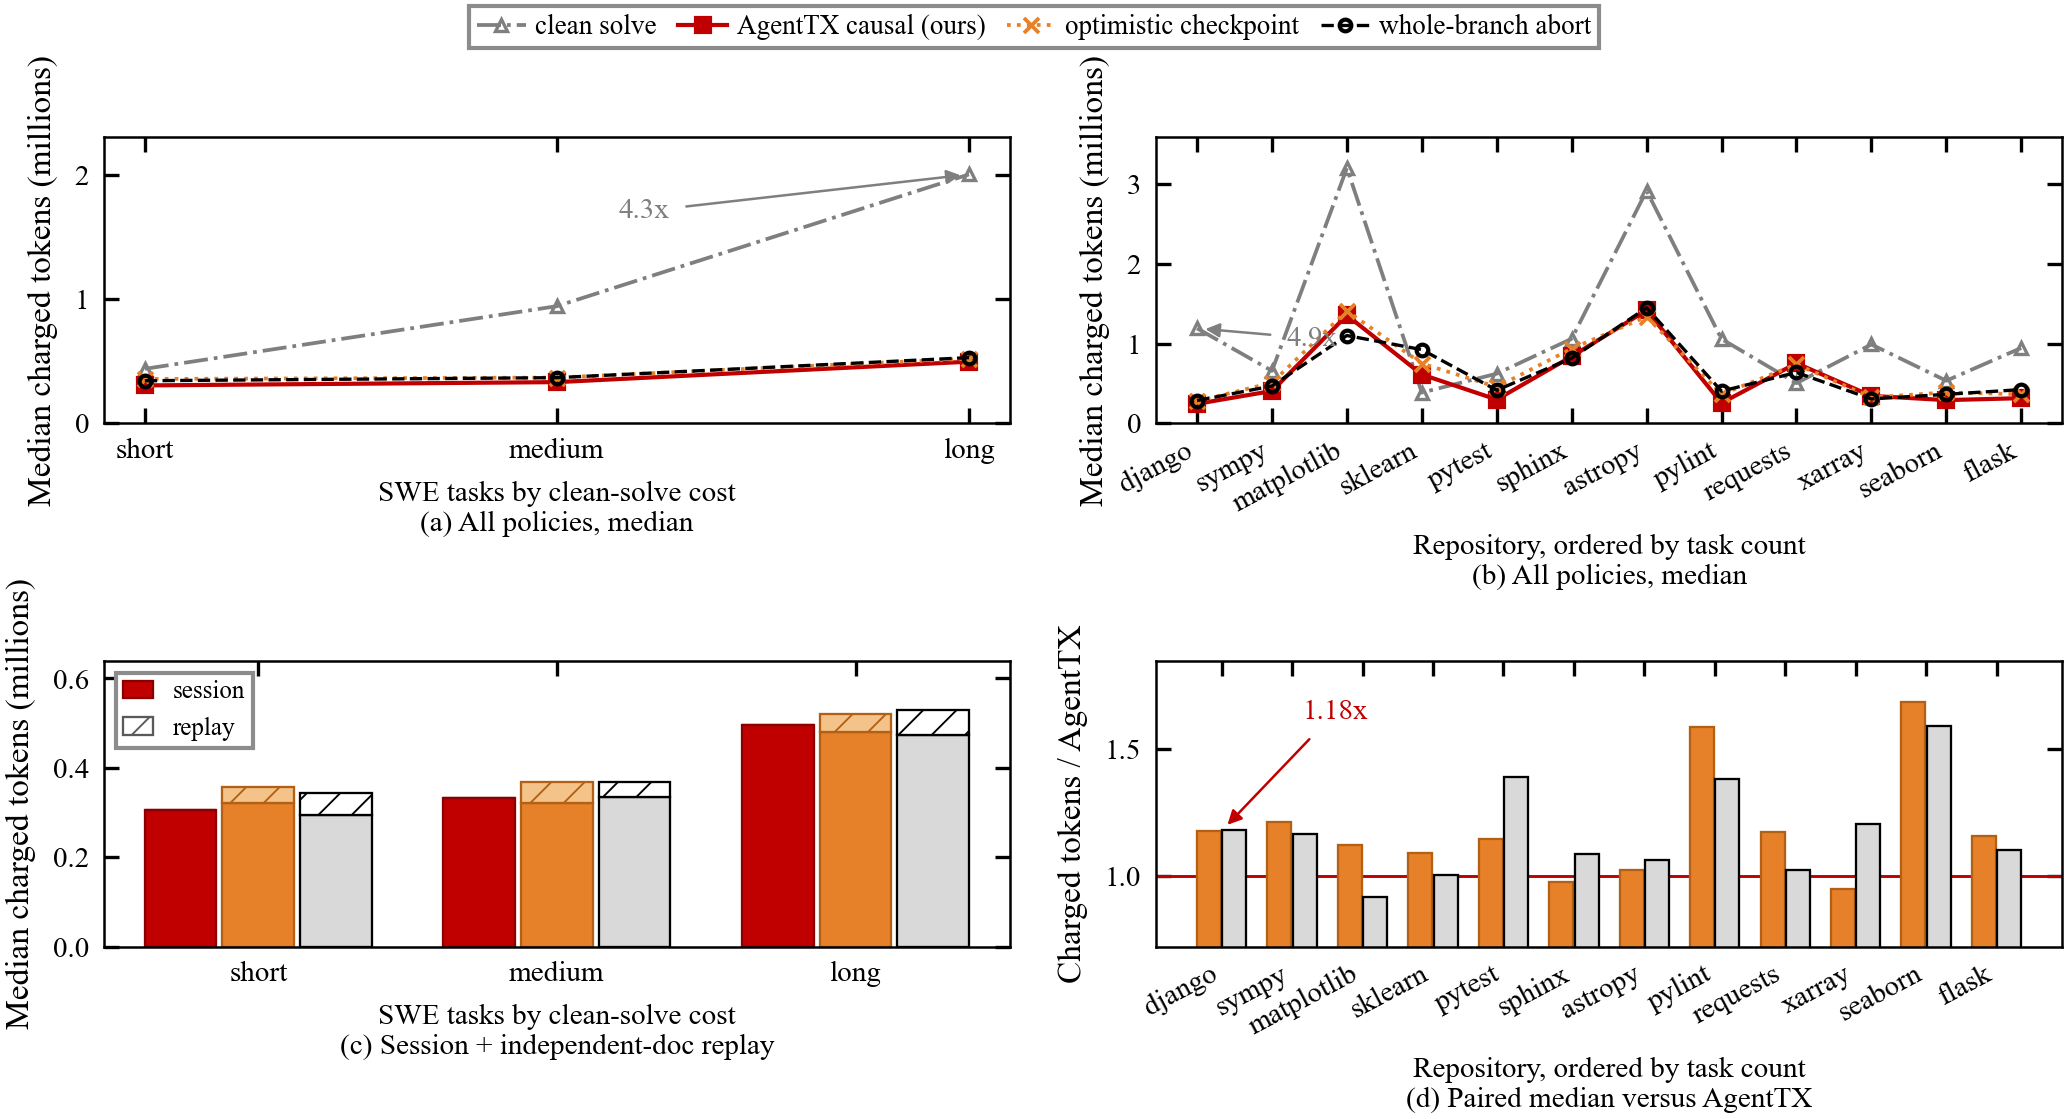

In [1]:
# ipython -c "%run plot_swe_tokens.ipynb"
# FAST/USENIX conventions: white panels, boxed top legend,
# red solid = ours. Token y-values are charged = session + replay.
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from pathlib import Path

try:
    get_ipython()
except NameError:
    matplotlib.use("Agg")

STANDARD_WIDTH = 17.8


def cm_to_inch(value):
    return value / 2.54


plt.rcParams.update(plt.rcParamsDefault)
matplotlib.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Nimbus Roman", "Times New Roman", "Times"]
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.linewidth"] = 0.6
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.edgecolor"] = "0.55"
plt.rcParams["legend.framealpha"] = 1.0
plt.rcParams["legend.fancybox"] = False
plt.rcParams["hatch.linewidth"] = 0.45
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

STYLES = {
    "no_fault": dict(
        color="#7f7f7f",
        marker="^",
        linestyle="-.",
        linewidth=0.9,
        markersize=3.0,
        markerfacecolor="none",
        markeredgewidth=0.8,
    ),
    "causal": dict(color="#c00000", marker="s", linestyle="-", linewidth=1.0, markersize=3.2),
    "temporal_checkpoint": dict(
        color="#e78129",
        marker="x",
        linestyle=":",
        linewidth=0.9,
        markersize=3.6,
        markeredgewidth=0.9,
    ),
    "whole_branch_abort": dict(
        color="black",
        marker="o",
        linestyle="--",
        linewidth=0.8,
        markersize=2.8,
        markerfacecolor="none",
    ),
}
BAR = {
    "causal": dict(facecolor="#c00000", edgecolor="#8a0000", hatch=""),
    "temporal_checkpoint": dict(facecolor="#e78129", edgecolor="#b35f14", hatch=""),
    "whole_branch_abort": dict(facecolor="#d9d9d9", edgecolor="black", hatch=""),
}
HATCH = {
    "causal": dict(facecolor="#c00000", edgecolor="#8a0000", hatch=""),
    "temporal_checkpoint": dict(facecolor="#f4c38a", edgecolor="#b35f14", hatch="///"),
    "whole_branch_abort": dict(facecolor="white", edgecolor="black", hatch="///"),
}
LABELS = {
    "no_fault": "clean solve",
    "causal": "AgentTX causal (ours)",
    "temporal_checkpoint": "optimistic checkpoint",
    "whole_branch_abort": "whole-branch abort",
}
MODES = list(STYLES)
COARSE = ["temporal_checkpoint", "whole_branch_abort"]

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "motivation" else cwd
FIGDIR = ROOT / "motivation"
PAPER = ROOT / "paper" / "img"
FIGDIR.mkdir(parents=True, exist_ok=True)
PAPER.mkdir(parents=True, exist_ok=True)
CSV = ROOT / "experiments" / "results" / "codex_7mode_full_r1_parallel_20260903" / "swe_official_tasks_raw.csv"

df = pd.read_csv(CSV)
df["total_tokens"] = pd.to_numeric(df["total_tokens"], errors="coerce").fillna(0.0)
df["doc_replay_tokens"] = pd.to_numeric(df["doc_replay_tokens"], errors="coerce").fillna(0.0)
df["charged"] = df["total_tokens"] + df["doc_replay_tokens"]
df["repo_short"] = df["repo"].astype(str).str.split("/").str[-1]
df.loc[df["repo_short"] == "scikit-learn", "repo_short"] = "sklearn"

SCALE_LABELS = ["short", "medium", "long"]
REPO_ORDER = (
    df.groupby("repo_short")["task"].nunique().sort_values(ascending=False).index.tolist()
)
sx = np.arange(len(SCALE_LABELS))
rx = np.arange(len(REPO_ORDER))

sess = df.pivot_table(index=["task", "repo_short"], columns="mode", values="total_tokens", aggfunc="first")
charged = df.pivot_table(index=["task", "repo_short"], columns="mode", values="charged", aggfunc="first")
nf = charged["no_fault"].reset_index(level=1, drop=True)
scale = pd.qcut(nf, 3, labels=SCALE_LABELS)


def scale_stat(frame, mode, how):
    series = frame[mode].reset_index(level=1, drop=True)
    out = []
    for label in SCALE_LABELS:
        chunk = series[scale == label]
        out.append(chunk.median() / 1e6 if how == "median" else chunk.sum() / 1e6)
    return out


def repo_stat(frame, mode, how="median"):
    ys = []
    for repo in REPO_ORDER:
        if repo not in frame.index.get_level_values(1):
            ys.append(np.nan)
            continue
        series = frame.xs(repo, level=1)[mode]
        ys.append(series.median() / 1e6 if how == "median" else series.sum() / 1e6)
    return ys


def paired_ratio_scale(frame, mode):
    causal = frame["causal"].reset_index(level=1, drop=True).replace(0, np.nan)
    series = frame[mode].reset_index(level=1, drop=True)
    ys = []
    for label in SCALE_LABELS:
        mask = scale == label
        ys.append(1.0 if mode == "causal" else float((series[mask] / causal[mask]).median()))
    return ys


def paired_ratio_repo(frame, mode):
    ys = []
    for repo in REPO_ORDER:
        block = frame.xs(repo, level=1)
        causal = block["causal"].replace(0, np.nan)
        ys.append(float((block[mode] / causal).median()))
    return ys


fig = plt.figure(dpi=300, figsize=(cm_to_inch(STANDARD_WIDTH), cm_to_inch(9.4)))
handles = []

ax = plt.subplot(2, 2, 1)
for mode in MODES:
    handle, = ax.plot(sx, scale_stat(charged, mode, "median"), **STYLES[mode], label=LABELS[mode])
    handles.append(handle)
ax.annotate(
    "4.3x",
    xy=(2, scale_stat(charged, "no_fault", "median")[2]),
    xytext=(1.15, 1.65),
    fontsize=7,
    color="#7f7f7f",
    arrowprops=dict(arrowstyle="-|>", color="#7f7f7f", lw=0.6),
)
ax.set_xticks(sx, SCALE_LABELS)
ax.set_ylim(0, 2.3)
ax.set_ylabel("Median charged tokens (millions)", fontsize=8)
ax.set_xlabel("SWE tasks by clean-solve cost\n(a) All policies, median", fontsize=7)

ax = plt.subplot(2, 2, 2)
repo_med = {mode: repo_stat(charged, mode, "median") for mode in MODES}
for mode in MODES:
    ax.plot(rx, repo_med[mode], **STYLES[mode])
dj_ratio = repo_med["no_fault"][0] / repo_med["causal"][0]
ax.annotate(
    f"{dj_ratio:.1f}x",
    xy=(0, repo_med["no_fault"][0]),
    xytext=(1.2, repo_med["no_fault"][0] * 0.82),
    fontsize=7,
    color="#7f7f7f",
    arrowprops=dict(arrowstyle="-|>", color="#7f7f7f", lw=0.6),
)
ax.set_xticks(rx, REPO_ORDER, rotation=28, ha="right")
ax.set_ylim(0, max(max(vals) for vals in repo_med.values()) * 1.12)
ax.set_ylabel("Median charged tokens (millions)", fontsize=8)
ax.set_xlabel("Repository, ordered by task count\n(b) All policies, median", fontsize=7)

ax = plt.subplot(2, 2, 3)
width = 0.24
offsets = {"causal": -0.26, "temporal_checkpoint": 0.0, "whole_branch_abort": 0.26}
for mode in ("causal", *COARSE):
    sess_m = np.array(scale_stat(sess, mode, "median"))
    charged_m = np.array(scale_stat(charged, mode, "median"))
    replay_h = np.clip(charged_m - sess_m, 0, None)
    ax.bar(sx + offsets[mode], sess_m, width=width, linewidth=0.55, **BAR[mode], zorder=2)
    ax.bar(
        sx + offsets[mode],
        replay_h,
        width=width,
        bottom=sess_m,
        linewidth=0.55,
        **HATCH[mode],
        zorder=3,
    )
ax.set_xticks(sx, SCALE_LABELS)
ax.set_ylim(0, 0.64)
ax.set_ylabel("Median charged tokens (millions)", fontsize=8)
ax.set_xlabel("SWE tasks by clean-solve cost\n(c) Session + independent-doc replay", fontsize=7)
ax.legend(
    handles=[
        Patch(facecolor="#c00000", edgecolor="#8a0000", linewidth=0.55, label="session"),
        Patch(facecolor="white", edgecolor="0.35", linewidth=0.55, hatch="///", label="replay"),
    ],
    loc="upper left",
    fontsize=6,
    frameon=True,
    handlelength=1.2,
    borderpad=0.28,
)

ax = plt.subplot(2, 2, 4)
ax.axhline(1.0, color="#c00000", linewidth=0.7, linestyle="-")
width = 0.34
for mode, off in (("temporal_checkpoint", -0.18), ("whole_branch_abort", 0.18)):
    ys = paired_ratio_repo(charged, mode)
    ax.bar(rx + off, ys, width=width, linewidth=0.55, zorder=2, **BAR[mode])
ax.set_xticks(rx, REPO_ORDER, rotation=28, ha="right")
ax.set_ylim(0.72, 1.85)
ax.set_ylabel("Charged tokens / AgentTX", fontsize=8)
ax.set_xlabel("Repository, ordered by task count\n(d) Paired median versus AgentTX", fontsize=7)
ax.annotate(
    "1.18x",
    xy=(0, paired_ratio_repo(charged, "temporal_checkpoint")[0]),
    xytext=(1.15, 1.62),
    fontsize=7,
    color="#c00000",
    arrowprops=dict(arrowstyle="-|>", color="#c00000", lw=0.6),
)

for axis in fig.axes:
    axis.tick_params(axis="both", labelsize=7, direction="in", top=True, right=True)

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=4,
    fontsize=6.5,
    columnspacing=0.8,
    handlelength=1.8,
    handletextpad=0.35,
    borderpad=0.3,
)
plt.tight_layout(pad=0.55, h_pad=1.7, w_pad=1.15, rect=[0.0, 0.0, 1.0, 0.92])
for dest in (FIGDIR, PAPER):
    fig.savefig(dest / "FIG-SWE-Tokens.pdf", bbox_inches="tight", pad_inches=0.02)
    fig.savefig(dest / "FIG-SWE-Token-Tasks.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
if matplotlib.get_backend().lower() != "agg":
    plt.show()

print(f"loaded {CSV}")
print("median charged", {label: {mode: round(scale_stat(charged, mode, "median")[i], 3) for mode in ("causal", *COARSE)} for i, label in enumerate(SCALE_LABELS)})
print("ratio by scale", {mode: [round(v, 3) for v in paired_ratio_scale(charged, mode)] for mode in COARSE})
print("ratio by repo", {mode: [round(v, 3) for v in paired_ratio_repo(charged, mode)] for mode in COARSE})
print("repo median", {mode: [round(v, 3) for v in repo_stat(charged, mode, "median")] for mode in MODES})
